In [1]:
import os
import pandas as pd
from collections import defaultdict

In [2]:
training_data = defaultdict(list)
testing_data = defaultdict(list)
real_testing_data = defaultdict(list)

training_path = "/home/dewei/workspace/SmellNet/data/offline_training"
testing_path = "/home/dewei/workspace/SmellNet/data/offline_training"
# real_testing_path = "/home/dewei/workspace/smell-net/processed_real_time_testing"
max_len = 0  # Track minimum length across all series
num_data = 0
count = 0

arrays_dict = defaultdict(list)
NO2_dict = defaultdict(list)

# Walk through the training directory
for folder_name in os.listdir(training_path):
    folder_path = os.path.join(training_path, folder_name)
    
    if os.path.isdir(folder_path):  # Make sure it's a folder
        for filename in os.listdir(folder_path):
            if filename.endswith(".csv"):
                cur_path = os.path.join(folder_path, filename)
                df = pd.read_csv(cur_path)
                training_data[folder_name].append(df)
                max_len = max(max_len, df.shape[0])  # Update minimum length
                num_data += df.shape[0]
                first_row = df.iloc[0]  # Extract time step 0
                if "NO2" in df.columns:
                    NO2_dict["NO2"].extend([num - first_row["NO2"] for num in df["NO2"].tolist()])
                for col in df.columns:
                    arrays_dict[col].append(first_row[col])

In [4]:
count

49

In [15]:
arrays_dict.keys()

dict_keys(['NO2', 'C2H5OH', 'VOC', 'CO', 'Alcohol', 'LPG', 'Benzene', 'Temperature', 'Pressure', 'Humidity', 'Gas_Resistance', 'Altitude'])

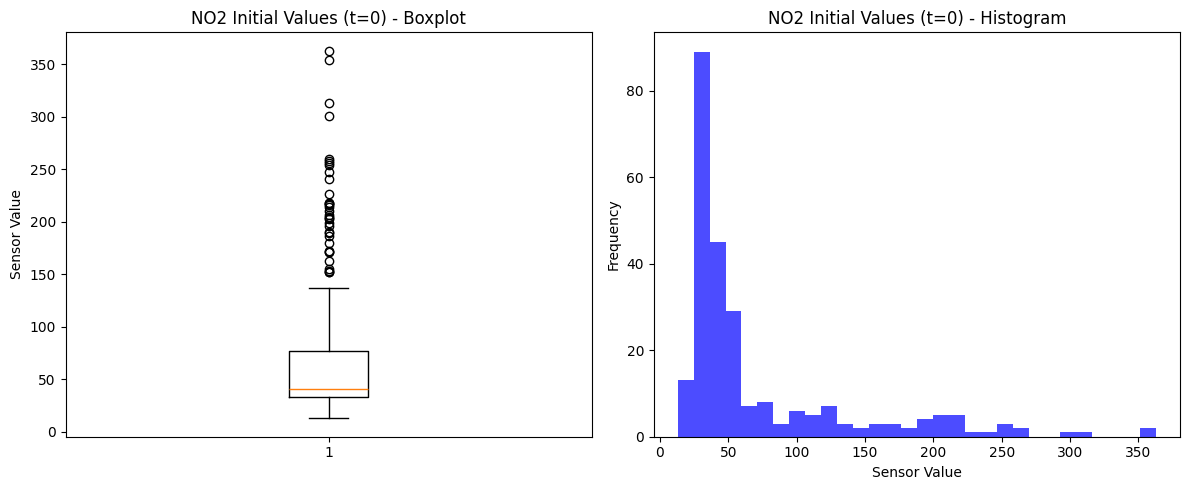

In [16]:
import matplotlib.pyplot as plt

def plot_training_sensor_distributions(training_arrays, sensor_name):
    """
    Plots boxplot and histogram for the specified sensor's initial values
    from the training dataset only.
    
    Args:
        training_arrays (dict): Dictionary of NumPy arrays for training initial values.
        sensor_name (str): Name of the sensor column (e.g., "NO2").
    """
    values = training_arrays.get(sensor_name, [])
    if len(values) == 0:
        print(f"No data found for sensor: {sensor_name}")
        return

    plt.figure(figsize=(12, 5))

    # Boxplot
    plt.subplot(1, 2, 1)
    plt.boxplot(values, vert=True)
    plt.title(f"{sensor_name} Initial Values (t=0) - Boxplot")
    plt.ylabel("Sensor Value")

    # Histogram
    plt.subplot(1, 2, 2)
    plt.hist(values, bins=30, alpha=0.7, color='blue')
    plt.title(f"{sensor_name} Initial Values (t=0) - Histogram")
    plt.xlabel("Sensor Value")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Example: Plot for NO2
plot_training_sensor_distributions(arrays_dict, "NO2")


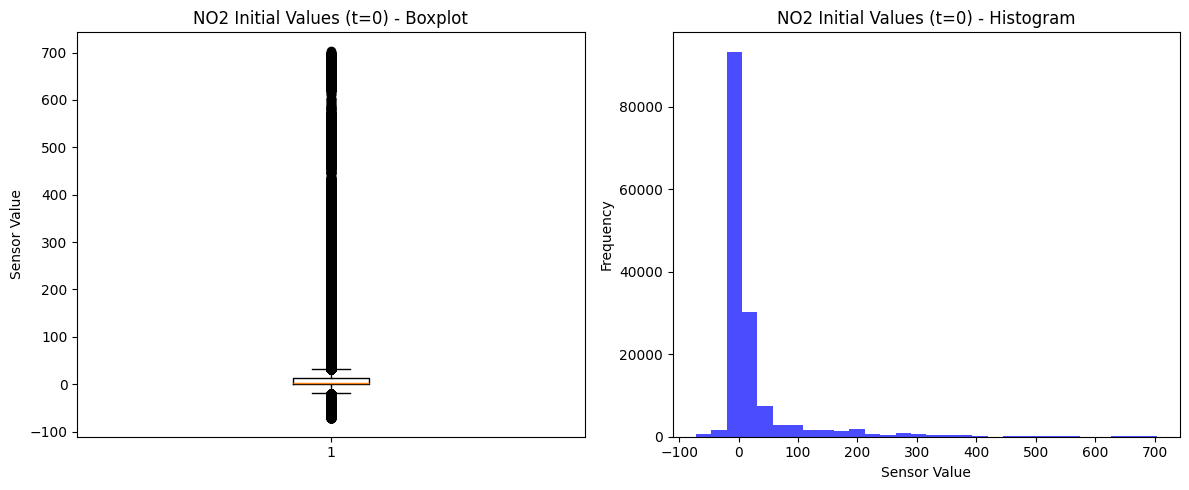

In [17]:
plot_training_sensor_distributions(NO2_dict, "NO2")

In [12]:
print(max(NO2_dict["NO2"]))

753


In [13]:
print(max(arrays_dict["NO2"]))

363.0


In [5]:
import numpy as np

def analyze_sensor_initial_values(training_arrays, sensor_name="NO2", threshold=100):
    """
    Analyze the initial values for a given sensor.
    
    Args:
        training_arrays (dict): Dictionary containing arrays of initial values for each sensor.
        sensor_name (str): The sensor column to analyze.
        threshold (float): Threshold for counting high values (e.g., NO2 > 100).
    """
    values = training_arrays.get(sensor_name, [])
    if len(values) == 0:
        print(f"No data available for sensor: {sensor_name}")
        return
    
    values = np.array(values)
    
    # Basic statistics
    mean_val = np.mean(values)
    median_val = np.median(values)
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    
    # Outlier detection (1.5 * IQR rule)
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = values[(values < lower_bound) | (values > upper_bound)]
    
    # High-value count
    high_count = np.sum(values > threshold)
    high_percentage = (high_count / len(values)) * 100
    
    # Print summary
    print(f"--- {sensor_name} Initial Values Analysis ---")
    print(f"Count: {len(values)}")
    print(f"Mean: {mean_val:.2f}")
    print(f"Median: {median_val:.2f}")
    print(f"Q1 (25%): {q1:.2f}, Q3 (75%): {q3:.2f}, IQR: {iqr:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"Outlier Count: {len(outliers)} ({len(outliers)/len(values)*100:.2f}%)")
    print(f"Values > {threshold}: {high_count} ({high_percentage:.2f}%)")
    
    return {
        "mean": mean_val,
        "median": median_val,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "outliers": outliers,
        "high_count": high_count,
        "high_percentage": high_percentage
    }

# Example usage for NO2
stats_no2 = analyze_sensor_initial_values(arrays_dict, "NO2", threshold=100)


--- NO2 Initial Values Analysis ---
Count: 150711
Mean: 97.80
Median: 46.00
Q1 (25%): 35.00, Q3 (75%): 105.00, IQR: 70.00
Lower Bound: -70.00, Upper Bound: 210.00
Outlier Count: 19583 (12.99%)
Values > 100: 39267 (26.05%)


In [16]:
import pandas as pd
import numpy as np
import glob
import os

def compute_channel_slope(csv_path, sensor_column='NO2', sampling_rate=1, window_minutes=2):
    """
    Compute the slope of a specified sensor channel (e.g., NO2) in the last `window_minutes` of the session.
    
    Args:
        csv_path (str): Path to the CSV file containing time series data.
        sensor_column (str): Name of the sensor column to analyze.
        sampling_rate (int): Sampling rate in Hz (default 1 Hz).
        window_minutes (int): Duration in minutes to consider for slope calculation.
        
    Returns:
        float: Slope of sensor readings in last `window_minutes` (units per minute).
    """
    df = pd.read_csv(csv_path)
    
    if sensor_column not in df.columns:
        raise ValueError(f"{sensor_column} column not found in {csv_path}")
    
    window_samples = window_minutes * 60 * sampling_rate
    if len(df) < window_samples:
        raise ValueError(f"File {csv_path} has fewer samples than the requested window.")
    
    values = df[sensor_column].values[-window_samples:]
    time_values = np.arange(len(values)) / sampling_rate / 60  # convert to minutes
    
    slope = np.polyfit(time_values, values, 1)[0]  # slope in units per minute
    return slope

def analyze_slope_across_sessions(data_dir, sensor_column='NO2', threshold=1.0):
    """
    Analyze slope across all CSV files in a directory and summarize stability.
    
    Args:
        data_dir (str): Directory containing CSV files for each session.
        sensor_column (str): Sensor column to analyze (default 'NO2').
        threshold (float): Threshold (units/min) for considering a slope "stable".
        
    Returns:
        dict: Mean slope, median slope, and percentage of sessions with |slope| < threshold.
    """
    slopes = []
    for csv_file in glob.glob(os.path.join(data_dir, "*.csv")):
        try:

            slope = compute_channel_slope(csv_file, sensor_column)
            slopes.append(slope)
        except Exception as e:
            print(f"Skipping {csv_file}: {e}")
    
    slopes = np.array(slopes)

    stats = {
        'mean_slope': np.mean(slopes),
        'median_slope': np.median(slopes),
        'percent_stable_sessions': np.sum(np.abs(slopes) < threshold) / len(slopes) * 100
    }
    return stats


In [19]:
import os
import pandas as pd


base_dir = "/home/dewei/workspace/SmellNet/data/offline_training"
sensor_column = "NO2"
results = []

for ingredient in sorted(os.listdir(base_dir)):
    ingredient_path = os.path.join(base_dir, ingredient)
    
    # Ensure it's a directory (each ingredient should be a folder)
    if os.path.isdir(ingredient_path):
        try:
            stats = analyze_slope_across_sessions(ingredient_path, sensor_column=sensor_column)
            results.append({
                "Ingredient": ingredient,
                "Mean Slope": stats['mean_slope'],
                "Median Slope": stats['median_slope'],
                "% Stable (<1 unit/min)": stats['percent_stable_sessions']
            })
        except Exception as e:
            print(f"Skipping {ingredient_path}: {e}")

# Convert to DataFrame
df = pd.DataFrame(results)
df_sorted = df.sort_values(by="Median Slope", ascending=False)

# Display results
print(df_sorted)

# Save to CSV if needed
df_sorted.to_csv("no2_slope_analysis_all_ingredients.csv", index=False)
print(stats)

         Ingredient  Mean Slope  Median Slope  % Stable (<1 unit/min)
26            lemon    8.613265     11.857907                     0.0
21             dill    5.501590      6.981526                     0.0
20            cumin    1.626738      4.774915                     0.0
2          angelica    2.843739      3.685464                    20.0
33          oregano    1.311591      2.698521                     0.0
18           cloves    3.534079      2.419751                     0.0
0          allspice    2.394791      2.275575                     0.0
17         cinnamon    1.285964      1.346552                     0.0
23           ginger    2.696687      1.141746                    40.0
22           garlic    0.754177      0.975901                    60.0
29             mint    1.058740      0.954233                    60.0
16           chives    0.822849      0.938815                    60.0
4         asparagus    1.138037      0.884645                    60.0
44       star_anise 

In [20]:
from collections import Counter

print(Counter(df_sorted["% Stable (<1 unit/min)"].to_list()))

Counter({100.0: 20, 80.0: 9, 0.0: 8, 60.0: 7, 40.0: 5, 20.0: 1})
